In [368]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from hmmlearn.hmm import GaussianHMM as hmm

In [373]:
n = 500
tf = 10
t = np.linspace(0,tf,n)

In [461]:
window = np.exp((-(t-tf/2)*(t-tf/2))/0.5)

X = np.array(
    [
        np.sin(40*t)*window,
        np.sin(2*t+np.pi/4)*window,
        np.sin(5*t),
        np.ones(n)
    ]
)

nc = X.shape[0]


noiseamp = 0.05*np.max(X)
noise = noiseamp*np.random.randn(nc,n)


Q = np.linalg.qr(np.random.rand(nc,nc)).Q


X_noised = pd.DataFrame((X+noise).T)
S = X_noised@Q
Z = S.ewm(alpha=0.8).mean()#((S-S.expanding().mean())/S.expanding().std()).fillna(0)

#Z.plot()

model = PCA(n_components=4)
recover = model.fit_transform(Z)
model.components_

array([[-0.28393277,  0.95686871, -0.03636482,  0.04961912],
       [ 0.61543512,  0.15095638,  0.19006868,  0.74988377],
       [ 0.67550424,  0.24309994,  0.22231209, -0.65967702],
       [-0.29037184, -0.05016837,  0.95557775,  0.00620478]])

Text(0.5, 1.0, 'PCA')

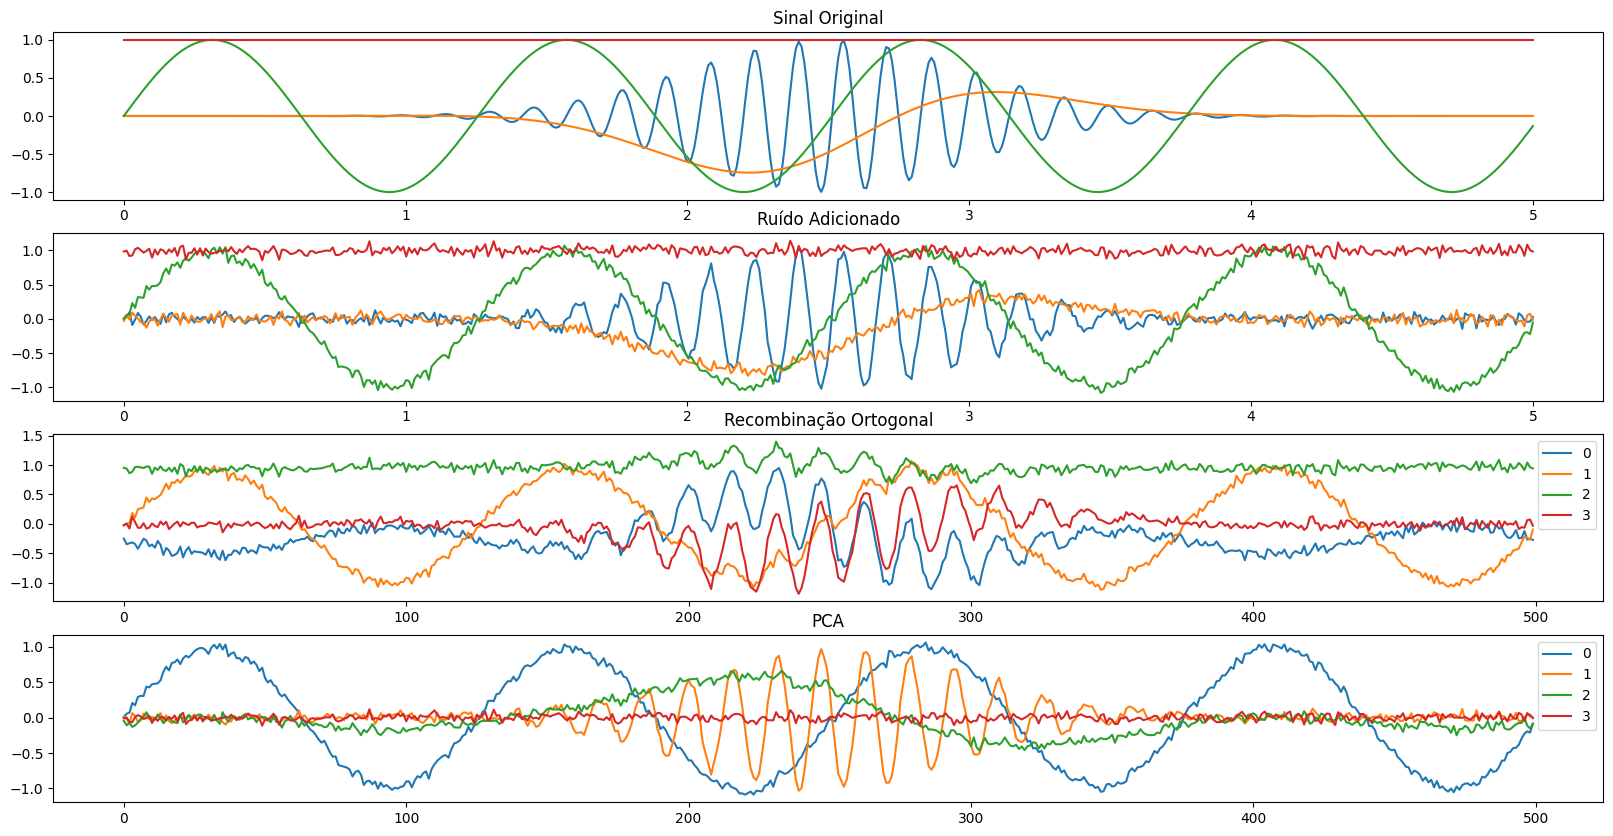

In [465]:
fig, axs = plt.subplots(4,1)

axs[0].plot(t,X.T)

axs[1].plot(t,X_noised)

S.plot(ax=axs[2],figsize=(20,10))



pd.DataFrame(recover).plot(ax=axs[3])

axs[0].set_title("Sinal Original")
axs[1].set_title("Ruído Adicionado")
axs[2].set_title("Recombinação Ortogonal")
axs[3].set_title("PCA")



